In [2]:
# !pip install docplex
# !pip install memory_profiler
# !pip install dwave-system
# !pip install gurobipy
# !pip install yfinance

In [1]:
###############################################################################
# // SPDX-License-Identifier: Apache-2.0
# // Copyright 2024: Amazon Web Services, Inc. - Contributions from JPMC
###############################################################################

import numpy as np
import pandas as pd
from itertools import product
import sys
sys.path.append("../")
from dcmppln.pipeline import Pipeline
from dcmppln.optimizer import GurobiOptimizer
from tests.input_data import InputData
from dcmppln.optimizer import SimulatedAnnealingDwave, NumpyOptimizer
import yfinance as yf
from typing import List
from dcmppln.denoiser import Denoiser, Denoiser_Shrinkage, Denoiser_Bayesian_PCA, Denoiser_PTSCDS, Denoiser_Bootstrap
from dcmppln.utils.preprocess_ticker_data import calculate_returns_correlations

Real market data

In [2]:
# List of stock markets
markets = {
    "payment_processors": ["V", "MA", "PYPL", "AXP", "DFS", "FI", "GPN", "FIS", "SQ", "ADP"],
    "defense_contractors": ["LMT", "RTX", "NOC", "GD", "BA", "HII", "TXT", "LDOS", "CW", "LHX"],
    "consumer_staples": ["PG", "KO", "PEP", "WMT", "COST", "CL", "MDLZ", "TGT", "SYY"], #"KHC", 
    "cloud_computing": ["MSFT", "AMZN", "GOOGL", "CRM", "ORCL", "IBM", "NOW", "DDOG", "ZS", "PANW"],
    "autonomous_vehicles": ["TSLA", "GM", "F", "GOOGL", "NVDA", "INTC", "MBLY", "APTIV", "TM", "LI"],
    "ecommerce_giants": ["AMZN", "BABA", "SHOP", "WMT", "EBAY", "MELI", "JD", "SE", "PDD", "TGT"],
    "biotech_innovators": ["BIIB", "REGN", "VRTX", "ILMN", "CRSP", "NTLA", "BEAM", "EDIT", "BMRN", "XBI"],
    "metaverse_stocks": ["META", "RBLX", "U", "NVDA", "MSFT", "GOOGL", "DIS", "SONY", "AAPL", "MTTR"],
    "cybersecurity_leaders": ["PANW", "FTNT", "CRWD", "ZS", "OKTA", "CHKP", "MSFT", "NET", "CYBR", "BUG"],
    "semiconductor_giants": ["NVDA", "AMD", "INTC", "TSM", "QCOM", "AVGO", "ASML", "TXN", "MU", "LRCX"],
    "green_energy": ["TSLA", "PLUG", "ENPH", "SEDG", "FSLR", "RUN", "NEE", "BE", "BLDP", "ICLN"],
    "space_exploration": ["SPCE", "RKLB", "BA", "LMT", "NOC", "IRDM", "AJRD", "MAXR", "AVAV", "UFO"],
    "tech_titans": ["AAPL", "MSFT", "NVDA", "AMZN", "GOOGL",  "TSLA", "QQQ", "VGT", "IGM"],#"META",
    "financial_giants": ["JPM", "BAC", "GS", "WFC", "C", "MS", "SCHW", "V", "MA", "XLF"],
    "retail_consumer": ["WMT", "TGT", "COST", "HD", "LOW", "ULTA", "NKE", "SBUX", "AMZN", "XRT"],
    "healthcare_leaders": ["UNH", "JNJ", "PFE", "MRK",  "LLY", "BMY", "TMO", "ISRG", "XLV"], #"ABBV",
    "energy_utilities": ["XOM", "CVX", "BP", "OXY", "COP", "ENB", "KMI", "NEE", "DUK", "XLE"],
    "industrial_powerhouses": ["CAT", "GE", "HON", "DE", "LMT", "BA", "MMM", "RTX", "EMR", "XLI"],
    "real_estate_reits": ["VNQ", "O", "SPG", "AMT", "CCI", "PSA", "VICI", "PLD", "WELL", "XLRE"],
    "entertainment_media": ["DIS", "NFLX", "CMCSA", "WBD", "PARA", "SPOT", "EA", "ROKU", "FOXA", "XLC"],  # Replaced SONY with EA
    "international_giants": ["BABA", "TSM", "ASML", "NVS", "SAP", "TM", "LVMUY", "RIO", "VALE", "IXUS"],
    "defensive_plays": ["KO", "PG", "JNJ", "MCD", "PEP", "WMT", "XLU", "VYM", "TLT", "VGIT"],
    }


In [ ]:
def download_data(stocks: List[str], start_date: str, end_date: str, period_step: int) -> pd.DataFrame:
    stock_data = {}
    for stock in stocks:
        ticker = yf.Ticker(stock)
        stock_data[stock] = ticker.history(start=start_date, end=end_date)["Close"][::period_step]
    return pd.DataFrame(stock_data)

# Define time period for analysis
start_date = "2010-07-01"
end_date = "2020-07-01"
period_step = 5  # Weekly changes

# Combine multiple markets into one big portfolio
markets_for_port=['tech_titans', 'healthcare_leaders', 'consumer_staples', 'semiconductor_giants','financial_giants', 'retail_consumer', 'industrial_powerhouses']
big_portfolio = [w for v in 
        [markets[c] for c in markets_for_port
                              ]
        for w in v
]
dataset = download_data(big_portfolio, start_date, end_date, period_step)

# Compute summary stats for PO
po_data = calculate_returns_correlations(dataset, True)

all_portfolios = [v for w in markets.values() for v in w]
len(all_portfolios)
all_portfolio_data = download_data(all_portfolios, start_date, end_date, period_step)

# Remove rows that are mostly null
all_portfolio_data2=all_portfolio_data[all_portfolio_data.isna().sum(axis=1)<150]

In [4]:
# Unpack summary stats
raw_returns = po_data.returns
returns = po_data.mean_returns
covariances = po_data.covariances
correlations = po_data.correlations

In [5]:

correlations.shape, covariances.shape, returns.shape

((62, 62), (62, 62), (62,))

$MBLY: possibly delisted; no price data found  (1d 2010-07-01 -> 2020-07-01) (Yahoo error = "Data doesn't exist for startDate = 1277956800, endDate = 1593576000")
$APTIV: possibly delisted; no timezone found
$LI: possibly delisted; no price data found  (1d 2010-07-01 -> 2020-07-01) (Yahoo error = "Data doesn't exist for startDate = 1277956800, endDate = 1593576000")
$RBLX: possibly delisted; no price data found  (1d 2010-07-01 -> 2020-07-01) (Yahoo error = "Data doesn't exist for startDate = 1277956800, endDate = 1593576000")
$U: possibly delisted; no price data found  (1d 2010-07-01 -> 2020-07-01) (Yahoo error = "Data doesn't exist for startDate = 1277956800, endDate = 1593576000")
$MTTR: possibly delisted; no price data found  (1d 2010-07-01 -> 2020-07-01) (Yahoo error = "Data doesn't exist for startDate = 1277956800, endDate = 1593576000")
$RKLB: possibly delisted; no price data found  (1d 2010-07-01 -> 2020-07-01) (Yahoo error = "Data doesn't exist for startDate = 1277956800, endDa

In [ ]:
#from tests.input_data import InputData

#input_data = InputData(path_name='seed_1000_size_90')


#correlations,covariances,returns = input_data.data_for_pipeline()

In [33]:

correlations.shape, covariances.shape, returns.shape

((90, 90), (90, 90), (90,))

 # Test Different Denoisers

In [63]:
active_denoisers = True
# RMT Denoiser published by JPM
rmt_denoiser = Denoiser(active=active_denoisers)
# Shrinkage Denoiser
shrinkage_denoiser = Denoiser_Shrinkage(active=active_denoisers)
# Bayesian PCA Denoiser
bayesianpca_denoiser = Denoiser_Bayesian_PCA(active=active_denoisers, data=dataset.to_numpy())
# PTSCDS Denoiser
ptscds_denoiser = Denoiser_PTSCDS(active=active_denoisers)
# Bootstrap Denoiser
bootstrap_denoiser = Denoiser_Bootstrap(active=active_denoisers)

In [64]:
# The function used in the pipeline for these is split_covariance_matrices

# rmt_denoiser, for reference
C_2, denoise_process_time, denoise_time=rmt_denoiser.denoise(correlations)
C_2


array([[ 3.39784994e-01, -3.91630598e-02,  3.23060141e-02, ...,
        -5.18774618e-02,  9.84837812e-02, -1.53439446e-02],
       [-3.91630598e-02,  4.20338714e-02,  1.79681309e-02, ...,
         2.28948697e-02, -1.23795971e-02,  4.10565426e-02],
       [ 3.23060141e-02,  1.79681309e-02,  6.50567203e-01, ...,
        -3.26300536e-02,  1.30100747e-01, -4.48819577e-02],
       ...,
       [-5.18774618e-02,  2.28948697e-02, -3.26300536e-02, ...,
         3.33977755e-02, -2.90098902e-02,  1.90866842e-02],
       [ 9.84837812e-02, -1.23795971e-02,  1.30100747e-01, ...,
        -2.90098902e-02,  2.03780881e-01, -1.96824432e-05],
       [-1.53439446e-02,  4.10565426e-02, -4.48819577e-02, ...,
         1.90866842e-02, -1.96824432e-05,  1.02333079e-01]])

In [65]:
# Shrinkage_denoiser, for reference
C_2, denoise_process_time, denoise_time=shrinkage_denoiser.denoise(correlations)
C_2

array([[ 8.52389482e-03, -7.72392724e-04, -3.69086358e-04, ...,
        -7.66872665e-04,  8.46029284e-04, -6.83366678e-04],
       [-7.72392724e-04,  5.14696404e-03,  3.00770221e-04, ...,
         6.31667108e-04, -5.30126806e-04,  8.59486407e-04],
       [-3.69086358e-04,  3.00770221e-04,  1.01473020e-02, ...,
        -3.86306288e-05, -4.49382530e-04, -1.41045613e-04],
       ...,
       [-7.66872665e-04,  6.31667108e-04, -3.86306288e-05, ...,
         3.91341773e-03, -6.65694482e-04,  2.53105957e-04],
       [ 8.46029284e-04, -5.30126806e-04, -4.49382530e-04, ...,
        -6.65694482e-04,  8.31975022e-03, -9.66022870e-05],
       [-6.83366678e-04,  8.59486407e-04, -1.41045613e-04, ...,
         2.53105957e-04, -9.66022870e-05,  7.05152940e-03]])

In [66]:
# Bayesian PCA, for reference
C_2, denoise_process_time, denoise_time=bayesianpca_denoiser.denoise(correlations)
C_2

array([[ 54.77943125, 131.33776036,   7.94218715, ...,   7.15355096,
         50.32358255, -12.58640114],
       [131.33776036, 403.34142462,  18.31292118, ..., -48.31970245,
         39.61150709, -77.90928752],
       [  7.94218715,  18.31292118,   4.09633143, ..., -16.57450879,
         -9.33321299,  -6.501828  ],
       ...,
       [  7.15355096, -48.31970245, -16.57450879, ..., 353.20332103,
        433.17297933, 139.22395171],
       [ 50.32358255,  39.61150709,  -9.33321299, ..., 433.17297933,
        585.73200198, 160.89376981],
       [-12.58640114, -77.90928752,  -6.501828  , ..., 139.22395171,
        160.89376981,  67.1152628 ]])

In [45]:
# PTSCDS, for reference
C_2, denoise_process_time, denoise_time=ptscds_denoiser.denoise(correlations)
C_2

TypeError: '<' not supported between instances of 'float' and 'NoneType'

In [46]:
# Bootstrap, for reference
C_2, denoise_process_time, denoise_time=bootstrap_denoiser.denoise(correlations)
C_2

TypeError: '<' not supported between instances of 'float' and 'NoneType'

# Re-Test Pipeline

In [ ]:

# create random portfolios
import random

# Construct a set of random porfolios
number_portfolios = 20
porfolio_sizes = [40,50,60,70,80]
portfolios = []
portfolio_returns = []
for i in range(number_portfolios):
    size = random.choice(porfolio_sizes)
    portfolios.append(random.sample(all_portfolios, size))
    dataset = all_portfolio_data2[portfolios[-1]].dropna(axis='column')
    portfolio_returns.append(calculate_returns_correlations(dataset, True))

In [109]:

# Initialize dataframe to store results
results_df = pd.DataFrame(columns=["Portfolio", 'PortfolioSize', "Run", "Distribution", "Optimizer", "Correlations", "Covariances", "Returns", "Score", "Solution"])
number_of_runs=100

for portfono, po_data in enumerate(portfolio_returns):

    # Unpack summary stats
    raw_returns = po_data.returns
    returns = po_data.mean_returns
    covariances = po_data.covariances
    correlations = po_data.correlations
    # 2a Run:

    for i in range(number_of_runs):
        denoisers = [Denoiser(),
                    Denoiser_Shrinkage(),
                    ]
        # Without denoising
        p = Pipeline(
            correlations,
            covariances,
            returns, 
            optimize_func=SimulatedAnnealingDwave(),
        )
        dct = p.run(run_optimizer=True)

        # Add results to dataframe
        results_df = pd.concat([results_df, pd.DataFrame([[portfono, len(portfolios[portfono]), i, "None", "Dwave", correlations, covariances, returns, dct['score'], dct['recombined_solution']]], 
                                                            columns=results_df.columns)], ignore_index=True)
        # With denoising
        p = Pipeline(
            correlations,
            covariances,
            returns, 
            optimize_func=SimulatedAnnealingDwave(),
            denoiser = Denoiser(active=True)
        )
        dct = p.run(run_optimizer=True)

        # Add results to dataframe
        results_df = pd.concat([results_df, pd.DataFrame([[portfono, len(portfolios[portfono]), i, 'MP', "Dwave", correlations, covariances, returns, dct['score'], dct['recombined_solution']]], 
                                                            columns=results_df.columns)], ignore_index=True)
        # With shrinkage
        p = Pipeline(
            correlations,
            covariances,
            returns, 
            optimize_func=SimulatedAnnealingDwave(),
            denoiser = Denoiser_Shrinkage(active=True)
        )
        dct = p.run(run_optimizer=True)

        # Add results to dataframe
        results_df = pd.concat([results_df, pd.DataFrame([[portfono, len(portfolios[portfono]), i, 'Shrinkage', "Dwave", correlations, covariances, returns, dct['score'], dct['recombined_solution']]], 
                                                            columns=results_df.columns)], ignore_index=True)

Objective value with this comm detection algorithm 0.41018972801327397
Communities found at level 1:  1
Objective value with this comm detection algorithm 0.4774480858407842
Communities found at level 1:  1


/tmp/ipykernel_7302/99534245.py:28: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_df = pd.concat([results_df, pd.DataFrame([[portfono, len(portfolios[portfono]), i, "None", "Dwave", correlations, covariances, returns, dct['score'], dct['recombined_solution']]],


Objective value with this comm detection algorithm 0.3840259862067607
Communities found at level 1:  1
Objective value with this comm detection algorithm 0.3922521588719706
Communities found at level 1:  1
Objective value with this comm detection algorithm 0.45544298257119387
Communities found at level 1:  1
Objective value with this comm detection algorithm 0.5098411005781697
Communities found at level 1:  1
Objective value with this comm detection algorithm 0.5356784067243991
Communities found at level 1:  1
Objective value with this comm detection algorithm 0.4955680384197478
Communities found at level 1:  1
Objective value with this comm detection algorithm 0.4228841456851916
Communities found at level 1:  1
Objective value with this comm detection algorithm 0.3713899323700084
Communities found at level 1:  1
Objective value with this comm detection algorithm 0.39896836883980474
Communities found at level 1:  1
Objective value with this comm detection algorithm 0.4641039115408258
C

In [110]:
# Display the results dataframe
portfosize=results_df.groupby('Portfolio')['PortfolioSize'].mean()

In [111]:
summary_df=results_df.groupby(['Portfolio', 'Distribution'])['Score'].describe().join(portfosize)

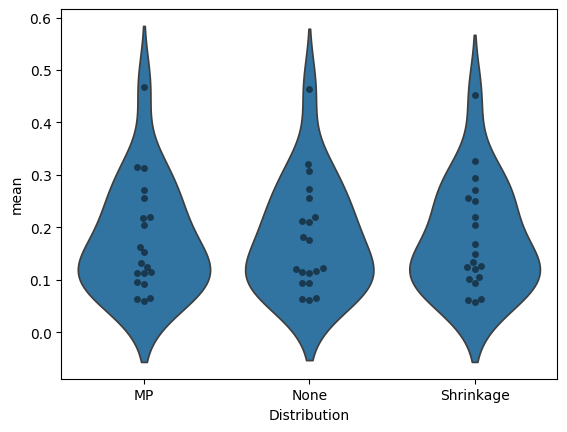

In [113]:
import seaborn as sns

# Create a paired violin plot
sns.violinplot(x='Distribution', y='mean', data=summary_df2, inner=None)
sns.swarmplot(x='Distribution', y='mean', data=summary_df2, color='k', alpha=0.5)

# Show the plot
plt.show()

The shrinkage denoiser, MP denoiser, and no denoiser show broadly similar distributions of mean scores